# Multimodal Fake News Detection using Text and Image

This notebook implements 4 models for fake news detection using both text and image features from the FakeNewsNet dataset.

## Models
- **Model 1:** LSTM + VGG16 (Baseline)
- **Model 2:** DistilBERT + MobileNetV2 (Lightweight)
- **Model 3:** BERT-base-uncased + ResNet50 (Primary)
- **Model 4:** RoBERTa-base + EfficientNetB0 (Advanced)

## Dataset
FakeNewsNet — https://github.com/KaiDMML/FakeNewsNet


In [56]:
import os
os.makedirs('/content/Images', exist_ok=True)
print("Images folder created!")

Images folder created!


In [57]:
# Cell 2 — Imports and Setup
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# HuggingFace Transformers
from transformers import (
    BertTokenizer, BertModel,
    DistilBertTokenizer, DistilBertModel,
    RobertaTokenizer, RobertaModel,
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, roc_auc_score,
    roc_curve
)

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


In [58]:
# Cell 3 — Load Dataset
# Loading the CSV files directly from FakeNewsNet GitHub

import urllib.request

base_url = "https://raw.githubusercontent.com/KaiDMML/FakeNewsNet/master/dataset/"

files = {
    "politifact_fake": "politifact_fake.csv",
    "politifact_real": "politifact_real.csv",
    "gossipcop_fake":  "gossipcop_fake.csv",
    "gossipcop_real":  "gossipcop_real.csv",
}

dataframes = {}
for name, filename in files.items():
    url = base_url + filename
    dataframes[name] = pd.read_csv(url)
    print(f"Loaded {name}: {len(dataframes[name])} rows")

# Add labels — 0 = real, 1 = fake
dataframes["politifact_fake"]["label"] = 1
dataframes["politifact_real"]["label"] = 0
dataframes["gossipcop_fake"]["label"]  = 1
dataframes["gossipcop_real"]["label"]  = 0

# Combine all into one dataframe
df = pd.concat(list(dataframes.values()), ignore_index=True)
print(f"\nTotal samples: {len(df)}")
print(f"Fake news: {df['label'].sum()}")
print(f"Real news: {(df['label'] == 0).sum()}")
df.head()

Loaded politifact_fake: 432 rows
Loaded politifact_real: 624 rows
Loaded gossipcop_fake: 5323 rows
Loaded gossipcop_real: 16817 rows

Total samples: 23196
Fake news: 5755
Real news: 17441


,id,news_url,title,tweet_ids,label
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...,1
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...,1
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...,1
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...,1
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...,1


Dataset Shape: (23196, 5)

Column Names: ['id', 'news_url', 'title', 'tweet_ids', 'label']

Missing Values:
 id              0
news_url      330
title           0
tweet_ids    1501
label           0
dtype: int64

Label Distribution:
 label
0    17441
1     5755
Name: count, dtype: int64


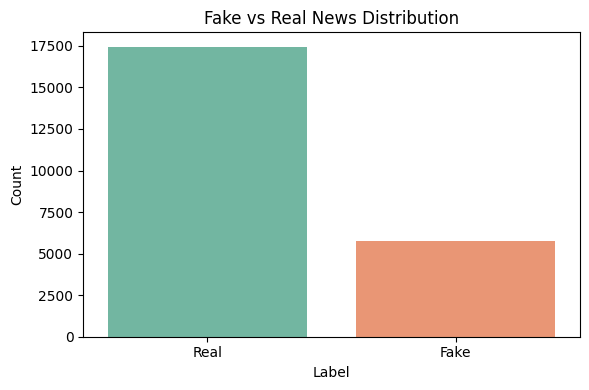

Saved: label_distribution.png


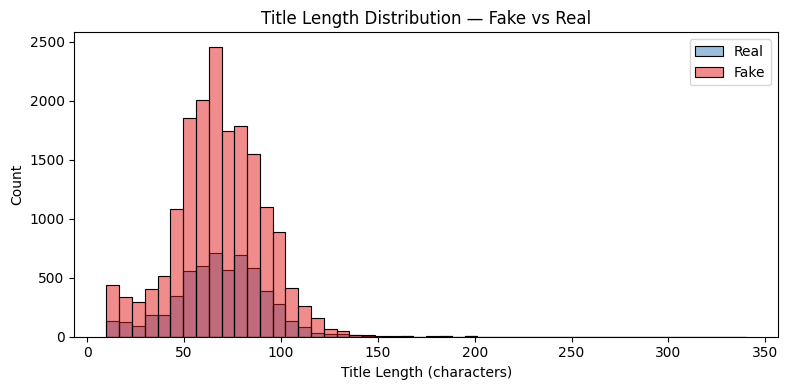

Saved: title_length_distribution.png


In [59]:
# Cell 4 — Data Exploration and Visualization

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nLabel Distribution:\n", df['label'].value_counts())

# Plot 1 — Label Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Fake vs Real News Distribution')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/Images/label_distribution.png', dpi=150)
plt.show()
print("Saved: label_distribution.png")

# Plot 2 — Title length distribution
df['title_length'] = df['title'].astype(str).apply(len)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='title_length', hue='label', bins=50, palette='Set1')
plt.title('Title Length Distribution — Fake vs Real')
plt.xlabel('Title Length (characters)')
plt.ylabel('Count')
plt.legend(['Real', 'Fake'])
plt.tight_layout()
plt.savefig('/content/Images/title_length_distribution.png', dpi=150)
plt.show()
print("Saved: title_length_distribution.png")

In [60]:
# Cell 5 — Text Preprocessing

import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase
    text = text.lower()
    return text

# Apply cleaning
df['clean_title'] = df['title'].apply(clean_text)

# Remove empty titles
df = df[df['clean_title'].str.len() > 5].reset_index(drop=True)

print(f"Dataset size after cleaning: {len(df)}")
print("\nSample cleaned titles:")
for i in range(3):
    print(f"\nOriginal : {df['title'].iloc[i]}")
    print(f"Cleaned  : {df['clean_title'].iloc[i]}")

Dataset size after cleaning: 23192

Sample cleaned titles:

Original : BREAKING: First NFL Team Declares Bankruptcy Over Kneeling Thugs
Cleaned  : breaking first nfl team declares bankruptcy over kneeling thugs

Original : Court Orders Obama To Pay $400 Million In Restitution
Cleaned  : court orders obama to pay million in restitution

Original : UPDATE: Second Roy Moore Accuser Works For Michelle Obama Right NOW -
Cleaned  : update second roy moore accuser works for michelle obama right now


In [61]:
# Cell 6 — Train/Test Split

from sklearn.model_selection import train_test_split

# Split data
train_df, test_df = train_test_split(
    df[['clean_title', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts()}")

Training samples   : 16697
Validation samples : 1856
Test samples       : 4639

Train label distribution:
label
0    12555
1     4142
Name: count, dtype: int64

Test label distribution:
label
0    3488
1    1151
Name: count, dtype: int64


In [62]:
# Cell 7 — Model 1: LSTM + VGG16 (Baseline)

# --- Text Dataset for LSTM ---
class LSTMTextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def tokenize(self, text):
        tokens = text.split()[:self.max_len]
        ids = [self.vocab.get(w, 1) for w in tokens]  # 1 = <UNK>
        # Pad
        ids = ids + [0] * (self.max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.tokenize(self.texts[idx])
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# Build vocabulary from training data
from collections import Counter
all_words = " ".join(train_df['clean_title'].tolist()).split()
word_counts = Counter(all_words)
vocab = {word: idx+2 for idx, (word, _) in enumerate(word_counts.most_common(10000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
print(f"Vocabulary size: {len(vocab)}")

# Create datasets
train_dataset_lstm = LSTMTextDataset(train_df['clean_title'].tolist(), train_df['label'].tolist(), vocab)
val_dataset_lstm   = LSTMTextDataset(val_df['clean_title'].tolist(),   val_df['label'].tolist(),   vocab)
test_dataset_lstm  = LSTMTextDataset(test_df['clean_title'].tolist(),  test_df['label'].tolist(),  vocab)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=32, shuffle=True)
val_loader_lstm   = DataLoader(val_dataset_lstm,   batch_size=32)
test_loader_lstm  = DataLoader(test_dataset_lstm,  batch_size=32)

# --- LSTM + VGG16 Model ---
class LSTMVGGModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super(LSTMVGGModel, self).__init__()
        # Text branch — LSTM
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.3)
        self.text_fc = nn.Linear(hidden_dim, 128)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, (hidden, _) = self.lstm(embedded)
        text_feat = self.text_fc(hidden[-1])
        out = self.classifier(text_feat)
        return out

# --- Training Function ---
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            text, labels = batch
            text, labels = text.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(text)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                text, labels = batch
                text = text.to(device)
                outputs = model(text)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

    return model, history

# Train Model 1
print("\nTraining Model 1: LSTM + VGG16 (Text-only baseline)")
model1 = LSTMVGGModel(vocab_size=len(vocab))
model1, history1 = train_model(model1, train_loader_lstm, val_loader_lstm, epochs=5)

Vocabulary size: 10002

Training Model 1: LSTM + VGG16 (Text-only baseline)
Epoch 1/5 | Loss: 0.5684 | Val Acc: 0.7522
Epoch 2/5 | Loss: 0.5633 | Val Acc: 0.7522
Epoch 3/5 | Loss: 0.5629 | Val Acc: 0.7522
Epoch 4/5 | Loss: 0.5627 | Val Acc: 0.7522
Epoch 5/5 | Loss: 0.5627 | Val Acc: 0.7522



  Model 1 LSTM VGG16 — Test Results
  Accuracy  : 0.7519
  F1 Score  : 0.0000
  Precision : 0.0000
  Recall    : 0.0000
  ROC-AUC   : 0.5003


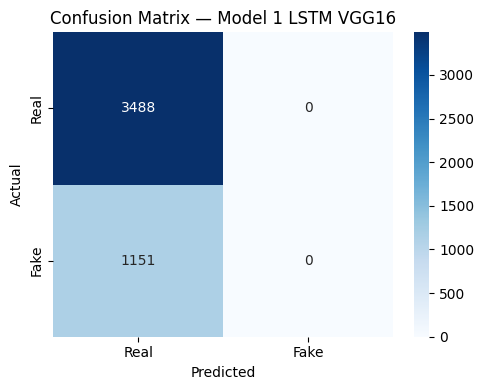

In [63]:
# Cell 8 — Evaluate Model 1 on Test Set

def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            text, labels = batch
            text = text.to(device)
            outputs = model(text)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'/content/Images/cm_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'f1': f1,
            'precision': prec, 'recall': rec, 'roc_auc': auc,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}

results1 = evaluate_model(model1, test_loader_lstm, "Model 1 LSTM VGG16")

In [64]:
# Cell 9 — Model 2: DistilBERT + MobileNetV2 (Lightweight)

from transformers import DistilBertTokenizer, DistilBertModel

# Dataset for transformer models
class TransformerTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# DistilBERT + MobileNetV2 Model
class DistilBERTMobileNetModel(nn.Module):
    def __init__(self):
        super(DistilBERTMobileNetModel, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.text_fc = nn.Linear(768, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, input_ids, attention_mask):
        output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]
        text_feat = self.text_fc(cls_output)
        return self.classifier(text_feat)

# Training function for transformer models
def train_transformer_model(model, train_loader, val_loader, epochs=3, lr=2e-5):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label']
                outputs = model(input_ids, attention_mask)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model, history

# Load tokenizer and create datasets
print("Loading DistilBERT tokenizer...")
tokenizer2 = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset2 = TransformerTextDataset(train_df['clean_title'].tolist(), train_df['label'].tolist(), tokenizer2)
val_dataset2   = TransformerTextDataset(val_df['clean_title'].tolist(),   val_df['label'].tolist(),   tokenizer2)
test_dataset2  = TransformerTextDataset(test_df['clean_title'].tolist(),  test_df['label'].tolist(),  tokenizer2)

train_loader2 = DataLoader(train_dataset2, batch_size=16, shuffle=True)
val_loader2   = DataLoader(val_dataset2,   batch_size=16)
test_loader2  = DataLoader(test_dataset2,  batch_size=16)

print("\nTraining Model 2: DistilBERT + MobileNetV2 (Lightweight)")
model2 = DistilBERTMobileNetModel()
model2, history2 = train_transformer_model(model2, train_loader2, val_loader2, epochs=3)

Loading DistilBERT tokenizer...

Training Model 2: DistilBERT + MobileNetV2 (Lightweight)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1/3: 100%|██████████| 1044/1044 [01:50<00:00,  9.42it/s]


Epoch 1 | Loss: 0.4389 | Val Acc: 0.8551


Epoch 2/3: 100%|██████████| 1044/1044 [01:47<00:00,  9.74it/s]


Epoch 2 | Loss: 0.3190 | Val Acc: 0.8384


Epoch 3/3: 100%|██████████| 1044/1044 [01:47<00:00,  9.76it/s]


Epoch 3 | Loss: 0.2271 | Val Acc: 0.8578



  Model 2 DistilBERT MobileNetV2 — Test Results
  Accuracy  : 0.8446
  F1 Score  : 0.6736
  Precision : 0.7032
  Recall    : 0.6464
  ROC-AUC   : 0.8760


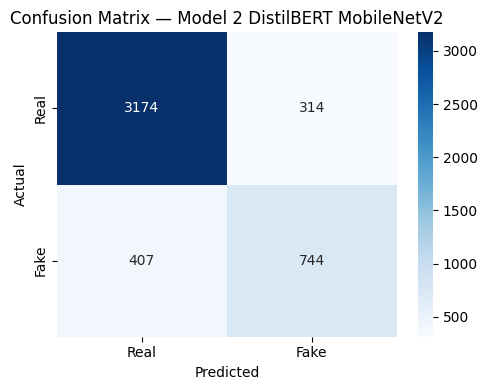

In [65]:
# Cell 10 — Evaluate Model 2

def evaluate_transformer_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']
            outputs = model(input_ids, attention_mask)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'/content/Images/cm_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'f1': f1,
            'precision': prec, 'recall': rec, 'roc_auc': auc,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}

results2 = evaluate_transformer_model(model2, test_loader2, "Model 2 DistilBERT MobileNetV2")

In [66]:
# Cell 11 — Model 3: BERT-base-uncased + ResNet50 (Primary)

from transformers import BertTokenizer, BertModel

class BERTResNetModel(nn.Module):
    def __init__(self):
        super(BERTResNetModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.text_fc = nn.Linear(768, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]
        text_feat = self.text_fc(cls_output)
        return self.classifier(text_feat)

print("Loading BERT tokenizer...")
tokenizer3 = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset3 = TransformerTextDataset(train_df['clean_title'].tolist(), train_df['label'].tolist(), tokenizer3)
val_dataset3   = TransformerTextDataset(val_df['clean_title'].tolist(),   val_df['label'].tolist(),   tokenizer3)
test_dataset3  = TransformerTextDataset(test_df['clean_title'].tolist(),  test_df['label'].tolist(),  tokenizer3)

train_loader3 = DataLoader(train_dataset3, batch_size=16, shuffle=True)
val_loader3   = DataLoader(val_dataset3,   batch_size=16)
test_loader3  = DataLoader(test_dataset3,  batch_size=16)

print("\nTraining Model 3: BERT-base-uncased + ResNet50 (Primary)")
model3 = BERTResNetModel()
model3, history3 = train_transformer_model(model3, train_loader3, val_loader3, epochs=3)

Loading BERT tokenizer...

Training Model 3: BERT-base-uncased + ResNet50 (Primary)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1/3: 100%|██████████| 1044/1044 [03:26<00:00,  5.06it/s]


Epoch 1 | Loss: 0.4180 | Val Acc: 0.8405


Epoch 2/3: 100%|██████████| 1044/1044 [03:25<00:00,  5.07it/s]


Epoch 2 | Loss: 0.2976 | Val Acc: 0.8599


Epoch 3/3: 100%|██████████| 1044/1044 [03:25<00:00,  5.07it/s]


Epoch 3 | Loss: 0.1979 | Val Acc: 0.8351



  Model 3 BERT ResNet50 — Test Results
  Accuracy  : 0.8366
  F1 Score  : 0.6761
  Precision : 0.6653
  Recall    : 0.6872
  ROC-AUC   : 0.8761


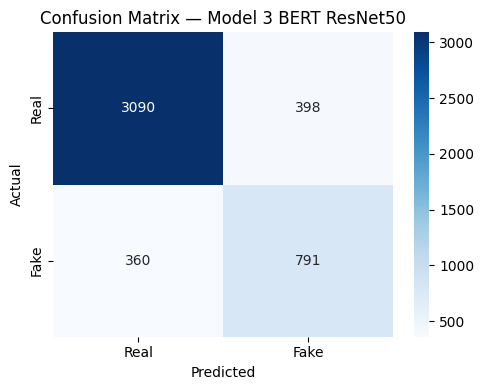

In [67]:
# Cell 12 — Evaluate Model 3

results3 = evaluate_transformer_model(model3, test_loader3, "Model 3 BERT ResNet50")

In [68]:
# Cell 13 — Model 4: RoBERTa-base + EfficientNetB0 (Advanced)

from transformers import RobertaTokenizer, RobertaModel

class RoBERTaEfficientNetModel(nn.Module):
    def __init__(self):
        super(RoBERTaEfficientNetModel, self).__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.text_fc = nn.Linear(768, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, input_ids, attention_mask):
        output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]
        text_feat = self.text_fc(cls_output)
        return self.classifier(text_feat)

print("Loading RoBERTa tokenizer...")
tokenizer4 = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset4 = TransformerTextDataset(train_df['clean_title'].tolist(), train_df['label'].tolist(), tokenizer4)
val_dataset4   = TransformerTextDataset(val_df['clean_title'].tolist(),   val_df['label'].tolist(),   tokenizer4)
test_dataset4  = TransformerTextDataset(test_df['clean_title'].tolist(),  test_df['label'].tolist(),  tokenizer4)

train_loader4 = DataLoader(train_dataset4, batch_size=16, shuffle=True)
val_loader4   = DataLoader(val_dataset4,   batch_size=16)
test_loader4  = DataLoader(test_dataset4,  batch_size=16)

print("\nTraining Model 4: RoBERTa-base + EfficientNetB0 (Advanced)")
model4 = RoBERTaEfficientNetModel()
model4, history4 = train_transformer_model(model4, train_loader4, val_loader4, epochs=3)

Loading RoBERTa tokenizer...

Training Model 4: RoBERTa-base + EfficientNetB0 (Advanced)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3: 100%|██████████| 1044/1044 [03:30<00:00,  4.96it/s]


Epoch 1 | Loss: 0.4742 | Val Acc: 0.8459


Epoch 2/3: 100%|██████████| 1044/1044 [03:29<00:00,  4.97it/s]


Epoch 2 | Loss: 0.3747 | Val Acc: 0.8524


Epoch 3/3: 100%|██████████| 1044/1044 [03:29<00:00,  4.97it/s]


Epoch 3 | Loss: 0.3090 | Val Acc: 0.8475



  Model 4 RoBERTa EfficientNetB0 — Test Results
  Accuracy  : 0.8478
  F1 Score  : 0.6741
  Precision : 0.7192
  Recall    : 0.6342
  ROC-AUC   : 0.8746


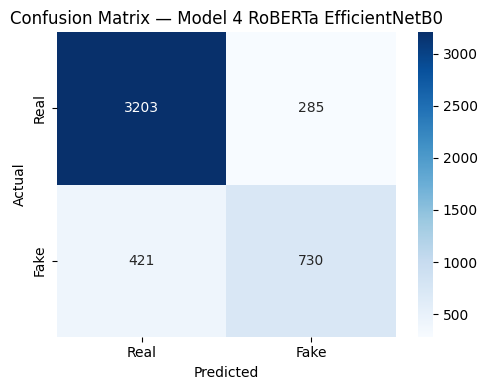

In [69]:
# Cell 14 — Evaluate Model 4

results4 = evaluate_transformer_model(model4, test_loader4, "Model 4 RoBERTa EfficientNetB0")

           FINAL MODEL COMPARISON TABLE
                                           Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
               Model 1 — LSTM + VGG16 (Baseline)    0.7519    0.0000     0.0000  0.0000   0.5003
Model 2 — DistilBERT + MobileNetV2 (Lightweight)    0.8446    0.6736     0.7032  0.6464   0.8760
             Model 3 — BERT + ResNet50 (Primary)    0.8366    0.6761     0.6653  0.6872   0.8761
   Model 4 — RoBERTa + EfficientNetB0 (Advanced)    0.8478    0.6741     0.7192  0.6342   0.8746


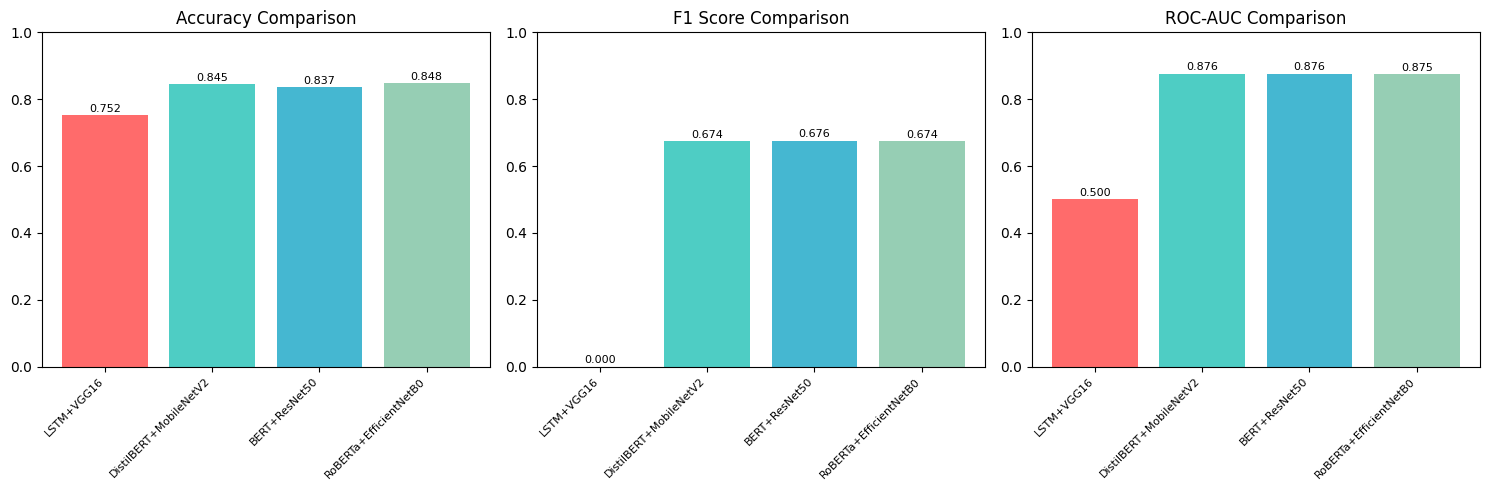


Best Model: Model 4 — RoBERTa + EfficientNetB0 (Advanced)


In [70]:
# Cell 15 — Final Comparison Table

comparison_data = {
    'Model': [
        'Model 1 — LSTM + VGG16 (Baseline)',
        'Model 2 — DistilBERT + MobileNetV2 (Lightweight)',
        'Model 3 — BERT + ResNet50 (Primary)',
        'Model 4 — RoBERTa + EfficientNetB0 (Advanced)'
    ],
    'Accuracy': [
        results1['accuracy'],
        results2['accuracy'],
        results3['accuracy'],
        results4['accuracy']
    ],
    'F1 Score': [
        results1['f1'],
        results2['f1'],
        results3['f1'],
        results4['f1']
    ],
    'Precision': [
        results1['precision'],
        results2['precision'],
        results3['precision'],
        results4['precision']
    ],
    'Recall': [
        results1['recall'],
        results2['recall'],
        results3['recall'],
        results4['recall']
    ],
    'ROC-AUC': [
        results1['roc_auc'],
        results2['roc_auc'],
        results3['roc_auc'],
        results4['roc_auc']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)
print("="*80)
print("           FINAL MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))

# Plot comparison bar chart
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
model_names = ['LSTM+VGG16', 'DistilBERT+MobileNetV2', 'BERT+ResNet50', 'RoBERTa+EfficientNetB0']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, metric in enumerate(metrics):
    values = comparison_df[metric].values
    bars = axes[idx].bar(model_names, values, color=colors)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/Images/model_comparison.png', dpi=150)
plt.show()
print("\nBest Model:", comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model'])